# Experiment C: is the positional penalty in the encoder or the decoder?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AgrfhyL/audio_model_initial_testing/blob/main/Colab_ExperimentC.ipynb)

Three things are already established in this repo:

1. Moving a short utterance from 5 s to 25 s inside the 30 s window raises corpus WER sharply —
   but **only when timestamp tokens are enabled**. With timestamps off the curve is flat.
2. The penalty shrinks with model scale without vanishing: tiny 14.4x, base 4.3x, small 3.6x,
   medium 2.2x.
3. Cyclically rolling the encoder positional embedding by -20 s restores baseline WER almost
   exactly.

Result 3 shows the positional embedding is **sufficient** to produce the effect, but it does not
localize it. Rolling the PE changes the encoder output, and the encoder output is what the decoder
cross-attends to — so "the PE fixes it" is equally consistent with two stories:

| | claim |
|---|---|
| **Encoder account** | placing audio at 25 s genuinely degrades the acoustic representation; the roll repairs it |
| **Decoder account** | the representation is fine, but carries an intact position signal the decoder mishandles once timestamp tokens are live; the roll removes the *cue*, not a *defect* |

This notebook separates them by measuring three things that free-running WER cannot see.

## The three measurements

**1. Reference evidence — teacher-forced text-token NLL.** Force the model down the reference
token sequence and score only the text tokens. This deletes search from the measurement: the path
is fixed by construction, so looping, the timestamp rules and the token cap cannot contribute.
What survives is a direct readout of whether the representation still supports the correct words.

$$\Delta\text{NLL} = \text{NLL}(25\,\text{s}) - \text{NLL}(5\,\text{s})$$

NLL *levels* are not comparable across model sizes — a large model is better everywhere — but
$\Delta$NLL is a within-model difference, so the model's baseline competence cancels. That is what
makes it the right cross-scale axis.

**2. Decoder pressure — the timestamp margin.** At each step, along a path matched by teacher
forcing, compute

$$\text{margin} = \log \sum_{t \ge \texttt{<|0.00|>}} p(t) \;-\; \max_{t < \texttt{<|0.00|>}} \log p(t)$$

This is **not an invented metric**. It is verbatim the decision variable of Whisper's own
`ApplyTimestampRules` (`decoding.py`):

```python
timestamp_logprob = logprobs[k, self.tokenizer.timestamp_begin :].logsumexp(dim=-1)
max_text_token_logprob = logprobs[k, : self.tokenizer.timestamp_begin].max()
if timestamp_logprob > max_text_token_logprob:
    logits[k, : self.tokenizer.timestamp_begin] = -np.inf
```

`margin > 0` means every text token is masked to `-inf` and the decoder is **forced** to emit a
timestamp. Crucially, that filter is installed only when `without_timestamps=False` — so the
margin is the precise mechanism by which the two arms can diverge while sharing an encoder.

**3. Generated behavior.** A free `decode()` on the same representation, instrumented past WER:
the timestamps actually emitted, output length against reference length, insertions, and whether
the sample cap was hit.

### What each account predicts

| | reference evidence | decoder pressure | generated behavior |
|---|---|---|---|
| **Encoder** | $\Delta$NLL shrinks with scale, tracking the 14.4→2.2 penalty | follows from the degraded representation | follows |
| **Decoder** | $\Delta$NLL stays similar across scale | margins and runaway paths shrink with scale | runaway rate falls while $\Delta$NLL does not |

The discriminator is the **shape across scale**, not any single model, so this must run on the
same ladder and the same 1000 clips as the earlier sweeps.

## Conditions

| | placement | positional embedding | forced timestamps describe |
|---|---|---|---|
| **C0** | 5 s | unmodified | 5 s |
| **C1** | 25 s | unmodified | 25 s |
| **C2** | 25 s | rolled -20 s | 5 s |

Each runs with timestamps on and off, giving 6 cells per (model, clip).

**Why C2's forced timestamps say 5 s.** The roll gives the frame at 25 s the embedding of the
frame at 5 s, so under C2 the model is *told* the audio sits at 5 s. Forcing `<|25.00|>` there
would score a path inconsistent with the model's own positional evidence and conflate the rescue
with a timestamp mismatch. Using the perceived position makes C2 a true rescue: if the roll is a
complete repair, every C2 number should return to C0.

**Why scoring reads raw logits.** `max_initial_timestamp=1.0` masks any first timestamp above
1.00 s to `-inf` during generation. Applying that mask while forcing `<|25.00|>` would make the
target unreachable and its NLL infinite, so the forced pass reads unmasked logits. The size of
what the rule *would* have removed is recorded instead, as `ts_forbidden_mass` — the probability
the model puts above 1.00 s at the first timestamp slot. That converts the known confound from a
caveat into a measured number.

## 1. Environment

Same base settings as the other Colab sweeps: GPU, fp16, greedy, batch 8.

In [1]:
!pip -q install openai-whisper jiwer soundfile

import subprocess, torch
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
                      "--format=csv,noheader"], capture_output=True, text=True).stdout.strip())
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
assert torch.cuda.is_available(), "Runtime > Change runtime type > GPU"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 47.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 123.6 MB/s eta 0:00:00
Tesla T4, 15360 MiB, 580.82.07
torch 2.11.0+cu128 | cuda True


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Provenance

Package versions, SHA-256 of the `whisper` source files that define the code path actually run,
each checkpoint verified against the digest embedded in its download URL, device and precision,
verbatim decoding options, and digests over both the audio arrays and the normalized references.

**Licensing.** TIMIT is LDC93S1 — licensed, not redistributable. Saving a Colab notebook back to
GitHub commits its outputs, so a printed transcript is a committed transcript. No transcript text
ever reaches printed output here. Hypotheses go to a Drive-only file; the git-safe file carries
paths and numbers only and is asserted to be so before writing.

In [3]:
import hashlib, json, os, platform

DRIVE_ROOT  = "/content/drive/MyDrive/NAACL"
RESULTS_CSV = os.path.join(DRIVE_ROOT, "expc_results_full.csv")    # has text -> Drive only
SAFE_CSV    = os.path.join(DRIVE_ROOT, "expc_per_utterance.csv")   # numbers only -> git-safe
PROV_JSON   = os.path.join(DRIVE_ROOT, "expc_provenance.json")
LOCAL_AUDIO = "/content/corpus"
REPO        = "AgrfhyL/audio_model_initial_testing"

def sha256_file(path, buf=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(buf), b""):
            h.update(chunk)
    return h.hexdigest()

def sha256_bytes(b):
    return hashlib.sha256(b).hexdigest()

import numpy, soundfile, jiwer, whisper

_wdir = os.path.dirname(whisper.__file__)
CODE_DIGESTS = {f: sha256_file(os.path.join(_wdir, f))[:16]
                for f in ("audio.py", "decoding.py", "model.py")}
try:
    import urllib.request
    with urllib.request.urlopen(
            f"https://api.github.com/repos/{REPO}/commits/main", timeout=10) as r:
        REPO_COMMIT = json.load(r)["sha"]
except Exception as e:
    REPO_COMMIT = f"unavailable ({type(e).__name__})"

PROVENANCE = {
    "experiment": "Experiment C -- localize the positional penalty: encoder or decoder",
    "conditions": "C0 5s | C1 25s | C2 25s PE-20s (timestamps describe perceived position)",
    "measurements": {
        "reference_evidence": "teacher-forced mean per-token NLL over text tokens only",
        "decoder_pressure": "logsumexp(timestamp logprobs) - max(text logprob), the decision "
                            "variable of whisper ApplyTimestampRules, along matched forced paths",
        "generated_behavior": "free decode(): timestamps emitted, lengths, insertions, cap hits",
    },
    "scoring_note": "forced pass reads raw logits; no LogitFilter applied. The mass "
                    "max_initial_timestamp would have removed is recorded as ts_forbidden_mass.",
    "packages": {
        "python": platform.python_version(), "openai-whisper": whisper.__version__,
        "torch": torch.__version__, "numpy": numpy.__version__,
        "soundfile": soundfile.__version__, "jiwer": getattr(jiwer, "__version__", "n/a"),
        "cuda": torch.version.cuda, "cudnn": torch.backends.cudnn.version(),
    },
    "code_version": {"whisper_source_sha256_16": CODE_DIGESTS, "repo": REPO,
                     "repo_commit": REPO_COMMIT},
    "device": {"name": torch.cuda.get_device_name(0),
               "capability": ".".join(map(str, torch.cuda.get_device_capability(0))),
               "precision": "fp16 (encoder/decoder); mel fp32 on CPU; logits cast to fp32"},
}
print(json.dumps(PROVENANCE, indent=1))

{
 "experiment": "Experiment C -- localize the positional penalty: encoder or decoder",
 "conditions": "C0 5s | C1 25s | C2 25s PE-20s (timestamps describe perceived position)",
 "measurements": {
  "reference_evidence": "teacher-forced mean per-token NLL over text tokens only",
  "decoder_pressure": "logsumexp(timestamp logprobs) - max(text logprob), the decision variable of whisper ApplyTimestampRules, along matched forced paths",
  "generated_behavior": "free decode(): timestamps emitted, lengths, insertions, cap hits"
 },
 "scoring_note": "forced pass reads raw logits; no LogitFilter applied. The mass max_initial_timestamp would have removed is recorded as ts_forbidden_mass.",
 "packages": {
  "python": "3.13.15",
  "openai-whisper": "20250625",
  "torch": "2.11.0+cu128",
  "numpy": "2.1.3",
  "soundfile": "0.14.0",
  "jiwer": "n/a",
  "cuda": "12.8",
  "cudnn": 91900
 },
 "code_version": {
  "whisper_source_sha256_16": {
   "audio.py": "36ed287b2de3eaf4",
   "decoding.py": "94084f

## 3. Corpus: the same 1000 clips

The full seed-0 draw from `corpus_digests.json`, so results join to the earlier sweeps by `path`.
Each clip is copied to local disk (Drive's FUSE mount is far too slow to read repeatedly) and
checked against its frozen `sha256_audio`, a digest over the decoded float32 samples.

In [4]:
import collections, glob, shutil, time
import numpy as np
import soundfile as sf

cands = [d for d in glob.glob(os.path.join(DRIVE_ROOT, "timit", "**", "TEST"), recursive=True)
         if os.path.isdir(os.path.join(d, "DR1"))]
assert cands, f"no TIMIT TEST/DR1 found under {DRIVE_ROOT}/timit"
TIMIT_TEST = sorted(cands, key=len)[0]

if not os.path.exists("corpus_digests.json"):
    !wget -q https://raw.githubusercontent.com/AgrfhyL/audio_model_initial_testing/main/corpus_digests.json
DIG = json.load(open("corpus_digests.json"))

def sha256_audio(a):
    return hashlib.sha256(np.ascontiguousarray(a, dtype=np.float32).tobytes()).hexdigest()

def load_reference(wav_path):
    with open(wav_path[:-4] + ".TXT") as f:
        return f.read().strip().split(None, 2)[2]

FILES, AUDIO, REFTEXT, bad = [], {}, {}, []
t0 = time.time()
for r in DIG["files"]:
    src = os.path.join(TIMIT_TEST, r["path"]); dst = os.path.join(LOCAL_AUDIO, r["path"])
    if not os.path.exists(dst):
        os.makedirs(os.path.dirname(dst), exist_ok=True); shutil.copy2(src, dst)
    a, sr = sf.read(dst, dtype="float32")
    if sr != DIG["sample_rate"] or len(a) != r["samples"] or sha256_audio(a) != r["sha256_audio"]:
        bad.append(r["path"]); continue
    AUDIO[r["path"]] = a; REFTEXT[r["path"]] = load_reference(src); FILES.append(r)

assert not bad, f"{len(bad)} clips fail their frozen digest, e.g. {bad[:3]}"
assert len(FILES) == 1000
spk = collections.Counter(r["speaker"] for r in FILES)
print(f"verified {len(FILES)} clips in {time.time()-t0:.0f}s | {len(spk)} speakers "
      f"({min(spk.values())}-{max(spk.values())} each) | "
      f"{sum(r['sec'] for r in FILES)/60:.1f} min audio")

verified 1000 clips in 1383s | 168 speakers (5-6 each) | 49.3 min audio


## 4. Conditions, the positional-embedding control, and the mel gate

`rolled_pe` is a context manager so the buffer is always restored — `load_model` caches, and a
leaked displacement would silently contaminate every later measurement. Restoration is asserted,
not assumed.

The mel gate is the control the whole comparison rests on: 5 s and 25 s must be exact
integer-frame shifts of each other, checked at both filterbank sizes since `large-v3` uses 128
mel bins where the smaller models use 80.

**Precision.** Same as every other Colab sweep here: the model is loaded fp32 and the *mel* is
cast to fp16, which is what `decode()` does internally. The encoder then returns fp16 features and
the decoder runs in fp16, while `TextDecoder.forward` casts logits back to fp32 before they are
returned — so the log-softmax is always fp32. Nothing ever calls `model.half()`, which matters
here: an fp32 -> fp16 -> fp32 round trip would permanently damage the weights and quietly
contaminate the fp32 leg of the precision check below.

In [5]:
import contextlib
from whisper.audio import log_mel_spectrogram, N_SAMPLES, SAMPLE_RATE, HOP_LENGTH
from whisper.normalizers import EnglishTextNormalizer

MODELS       = ["tiny", "base", "small", "medium", "large-v3"]
BATCH        = 8                  # divides 1000 exactly; fits large-v3 on a T4
PE_FPS       = 50                 # 1500 encoder frames / 30 s
TS_PRECISION = 0.02               # CHUNK_LENGTH / n_audio_ctx = 30 / 1500
MAX_INIT_TS  = 1.0                # stock max_initial_timestamp

# name, offset_s, pe_shift_s, ts_ref_s (what the forced timestamps describe)
CONDITIONS = [("C0",  5, None,  5),
              ("C1", 25, None, 25),
              ("C2", 25,  -20,  5)]
OFFSETS_S  = sorted({c[1] for c in CONDITIONS})

BASE_OPTS = dict(task="transcribe", language="en", temperature=0.0, beam_size=None,
                 best_of=None, prompt=None, prefix=None, fp16=True,
                 suppress_blank=True, suppress_tokens="-1",
                 max_initial_timestamp=MAX_INIT_TS)


@contextlib.contextmanager
def rolled_pe(model, seconds):
    """Cyclically roll the encoder positional embedding by `seconds`.

    Frame t receives the embedding of frame (t - seconds*PE_FPS) mod n_ctx, so every row stays a
    genuine training-time position. Rebuilding sinusoids at shifted positions instead would give
    leading-silence frames negative positions the model never saw, which is catastrophic
    (measured elsewhere in this repo: corpus WER 0.0586 -> 6.4163). Restores the buffer on exit.
    """
    pe = model.encoder.positional_embedding
    saved = pe.detach().clone()
    try:
        if seconds:
            pe.copy_(torch.roll(saved, shifts=int(-seconds * PE_FPS), dims=0))
        yield
    finally:
        pe.copy_(saved)
        assert torch.equal(pe, saved), "positional embedding was not restored"


def place(audio, off_s):
    buf = np.zeros(N_SAMPLES, dtype=np.float32)
    o = off_s * SAMPLE_RATE
    buf[o:o + len(audio)] = audio
    return buf


def mel_of(audio, off_s, n_mels):
    return log_mel_spectrogram(torch.from_numpy(place(audio, off_s)), n_mels)


normalizer = EnglishTextNormalizer()
REF = {p: normalizer(t) for p, t in REFTEXT.items()}
assert all(v.strip() for v in REF.values())

for s in OFFSETS_S:
    assert (s * SAMPLE_RATE) % HOP_LENGTH == 0
for r in FILES:
    for s in OFFSETS_S:
        assert s * SAMPLE_RATE + r["samples"] <= N_SAMPLES, (r["path"], s)
assert len(FILES) % BATCH == 0, f"{len(FILES)} not divisible by BATCH={BATCH}"

# --- mel gate: 5 s vs 25 s bit-identical, at both filterbank sizes ---
import random as _random
FPS, NF = SAMPLE_RATE // HOP_LENGTH, N_SAMPLES // HOP_LENGTH
gate = {}
for n_mels in (80, 128):
    worst = 0.0
    for r in _random.Random(7).sample(FILES, min(40, len(FILES))):
        a = AUDIO[r["path"]]; nf = int(np.ceil(len(a) / HOP_LENGTH)) + 2
        m5, m25 = mel_of(a, 5, n_mels).numpy(), mel_of(a, 25, n_mels).numpy()
        n = min(nf, NF - 25 * FPS)
        worst = max(worst, float(np.abs(m25[:, 25*FPS:25*FPS+n] - m5[:, 5*FPS:5*FPS+n]).max()))
    gate[n_mels] = worst
    assert worst == 0.0, f"mel gate FAILED at n_mels={n_mels}: {worst:.3e}"

corpus_digest = sha256_bytes("\n".join(
    f"{r['path']}\t{r['sha256_audio']}" for r in FILES).encode())
reference_digest = sha256_bytes("\n".join(
    f"{r['path']}\t{REF[r['path']]}" for r in FILES).encode())
PROVENANCE["decoding"] = {**BASE_OPTS, "greedy": True, "batch": BATCH,
                          "conditions": CONDITIONS}
PROVENANCE["corpus"] = {
    "source": "TIMIT (LDC93S1) TEST -- licensed, not redistributable",
    "spec_sha256": sha256_file("corpus_digests.json"), "n_clips": len(FILES),
    "n_speakers": len({r["speaker"] for r in FILES}),
    "corpus_digest_sha256": corpus_digest, "reference_digest_sha256": reference_digest,
}
PROVENANCE["mel_gate"] = {"offsets_compared": OFFSETS_S, "max_abs_dev_by_n_mels": gate}
print("mel gate: 5 s vs 25 s bit-identical at " +
      ", ".join(f"n_mels={k} (|dev| {v:.1e})" for k, v in gate.items()))
print("corpus digest   ", corpus_digest)
print("reference digest", reference_digest)

mel gate: 5 s vs 25 s bit-identical at n_mels=80 (|dev| 0.0e+00), n_mels=128 (|dev| 0.0e+00)
corpus digest    e96c305897ff0c609b59df8a9ae3d9674a88e43da02012208f8d4114f8c026ed
reference digest 4f2ad94b75048e39ba9b81ef26bc97db8c7ce7abb413c675c0a777ca2ab2245a


## 5. Teacher-forcing machinery

`Whisper.logits(tokens, audio_features)` calls the decoder with `kv_cache=None`, which runs a
single non-cached forward under the causal mask — exactly teacher forcing.

Two properties make this both cheap and tight:

- **Sequences are right-padded with EOT.** Under a causal mask a token cannot attend to later
  positions, so the padding is inert; this is verified below against unbatched scoring.
- **The encoder runs once per (batch, condition).** `DecodingTask._get_audio_features` skips
  encoding entirely when handed a tensor already shaped `(B, n_audio_ctx, n_audio_state)`, so one
  `audio_features` feeds the forced pass, the free decode and both timestamp arms. Beyond the
  saving, this guarantees all three measurement families read one bit-identical representation
  instead of three recomputations of it — and it means `rolled_pe` only has to wrap the encoder
  call, so a displacement cannot leak into decoding.

Token layouts. `sample_begin` is the first scored position; position `j-1` predicts token `j`:

```
forced,    ts on    [sot, en, transcribe, <|ts_start|>] + text + [<|ts_end|>, eot]
forced,    ts off   [sot, en, transcribe, <|notimestamps|>] + text + [eot]
generated, ts on    [sot, en, transcribe] + decode() tokens + [eot]
generated, ts off   [sot, en, transcribe, <|notimestamps|>] + decode() tokens + [eot]
```

`margin_*` is reported over steps whose correct continuation is a **text** token — that is the
set where a timestamp would be an intrusion into the transcript, and so the set where crossing
zero is what breaks the output.

In [6]:
def ts_token(tok, t_s):
    i = int(round(t_s / TS_PRECISION))
    assert 0 <= i <= 1500, f"timestamp {t_s}s falls outside the 30 s window"
    return tok.timestamp_begin + i


def forced_path(tok, ref_text, ts_on, ts_ref_s, dur_s):
    """The reference path. `ts_ref_s` is the position the forced timestamps describe."""
    body = tok.encode(" " + ref_text.strip())
    if ts_on:
        pre  = list(tok.sot_sequence) + [ts_token(tok, ts_ref_s)]
        post = [ts_token(tok, ts_ref_s + dur_s), tok.eot]
    else:
        pre  = list(tok.sot_sequence_including_notimestamps)
        post = [tok.eot]
    return pre, body, post


def generated_path(tok, ts_on, gen_tokens):
    """The model's own output re-scored. decode() returns the sampled body, EOT-exclusive."""
    pre = list(tok.sot_sequence) if ts_on else list(tok.sot_sequence_including_notimestamps)
    return pre, list(gen_tokens), [tok.eot]


def score_paths(model, tok, af, paths, first_ts=False, steps=False, true_ts_s=0.0):
    """One teacher-forced decoder pass over `af`; `paths` is a list of (pre, body, post).

    All rows in a call share |pre|, which every layout above satisfies. Returns one dict per path.
    """
    TSB, EOT = tok.timestamp_begin, tok.eot
    sb = len(paths[0][0])
    assert all(len(p[0]) == sb for p in paths), "ragged sample_begin within a batch"
    full = [p + b + q for p, b, q in paths]
    T = max(len(s) for s in full)
    assert T <= model.dims.n_text_ctx, f"sequence of {T} exceeds n_text_ctx"

    toks = torch.full((len(full), T), EOT, dtype=torch.long)
    for i, s in enumerate(full):
        toks[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    toks = toks.to(af.device)
    with torch.no_grad():
        lp = torch.log_softmax(model.logits(toks, af).float(), dim=-1)

    tgt, step = toks[:, 1:], lp[:, :-1]                       # step j-1 predicts token j
    nll_all = -step.gather(2, tgt.unsqueeze(-1)).squeeze(-1)
    # verbatim the decision variable of whisper's ApplyTimestampRules
    margin_all = step[:, :, TSB:].logsumexp(-1) - step[:, :, :TSB].max(-1).values

    if first_ts:                                              # the max_initial_timestamp slot
        # Renormalised *within* the timestamp block, i.e. conditional on emitting a timestamp.
        # That is the distribution ApplyTimestampRules actually samples from: at this position
        # it masks every text token to -inf first. Unconditional mass here is ~1e-5, since
        # unmasked the model would rather emit text -- interpretable only after conditioning.
        lp_ts = lp[:, sb - 1, TSB:TSB + 1501]
        tot   = lp_ts.logsumexp(-1)                           # log P(any timestamp)
        p1    = (lp_ts - tot.unsqueeze(-1)).exp()
        pi  = (p1.argmax(-1) * TS_PRECISION).cpu().numpy()
        pp  = p1.max(-1).values.cpu().numpy()
        fbd = p1[:, int(round(MAX_INIT_TS / TS_PRECISION)) + 1:].sum(-1).cpu().numpy()
        tsm = tot.cpu().numpy()
        # conditional mass within +/-0.5 s of where the audio actually starts: does the model
        # know where the utterance is, independently of whether the cap lets it say so?
        k, w = int(round(true_ts_s / TS_PRECISION)), int(round(0.5 / TS_PRECISION))
        tru = p1[:, max(0, k - w):k + w + 1].sum(-1).cpu().numpy()

    nll_np, mg_np = nll_all.cpu().numpy(), margin_all.cpu().numpy()
    tgt_np = tgt.cpu().numpy()

    out = []
    for i, (pre, body, post) in enumerate(paths):
        n = len(pre) + len(body) + len(post)
        sl = slice(sb - 1, n - 1)                             # predicts tokens[sb:n]
        t, nl, mg = tgt_np[i, sl], nll_np[i, sl], mg_np[i, sl]
        is_text = t < EOT
        nan = float("nan")
        d = {"n_text_tok": int(is_text.sum()),
             "nll_text": float(nl[is_text].mean()) if is_text.any() else nan,
             "nll_eot":  float(nl[t == EOT][0]) if (t == EOT).any() else nan,
             "margin_mean":    float(mg[is_text].mean()) if is_text.any() else nan,
             "margin_max":     float(mg[is_text].max())  if is_text.any() else nan,
             "margin_fracpos": float((mg[is_text] > 0).mean()) if is_text.any() else nan,
             # crossings that would interrupt the transcript: text steps only. Counting every
             # step instead would always include the legitimate closing-timestamp step.
             "n_margin_pos": int((mg[is_text] > 0).sum()) if is_text.any() else 0,
             # first crossing over all steps -- the meaningful form for a generated path,
             # where a crossing is precisely what forced the timestamp that was emitted
             "margin_first_pos": int(np.argmax(mg > 0)) if (mg > 0).any() else -1}
        ts_at = np.flatnonzero(t >= TSB)
        d["nll_ts_first"] = float(nl[ts_at[0]])  if len(ts_at) else nan
        d["nll_ts_last"]  = float(nl[ts_at[-1]]) if len(ts_at) else nan
        if first_ts:
            d.update(ts_pref_s=float(pi[i]), ts_pref_p=float(pp[i]),
                     ts_forbidden_mass=float(fbd[i]), ts_mass_logp=float(tsm[i]),
                     ts_true_mass=float(tru[i]))
        if steps:
            d["_tgt"], d["_margin"] = t, mg
        out.append(d)
    return out


print("machinery defined")

machinery defined


### Self-checks

Three things could quietly invalidate the measurement, so each is checked on the real hardware
before the sweep starts, using `base`.

1. **Padding must be inert** — batched scoring against one-at-a-time scoring. Hard-asserted.
2. **fp16 must not swamp the effect.** $\Delta$NLL is small, order 0.02–0.05 nats. Systematic
   fp16 bias largely cancels inside a within-model difference; what has to be shown is that the
   residual noise is small next to the effect once averaged over 1000 clips. Reported, not
   asserted, so a marginal result stays visible rather than killing a long run.
3. **The margin must reproduce Whisper's own behaviour.** When `margin > 0`, `ApplyTimestampRules`
   masks every text token to `-inf`, so a freely generating decoder *must* emit a timestamp at
   that step. The check is that implication, position by position, along paths the model actually
   generated. (The converse does not hold — a timestamp can also be emitted as an ordinary argmax,
   or be forced by the pairing rules — so equality is the wrong test.)

In [7]:
import gc

_chk = whisper.load_model("base", device="cuda")            # stays fp32; only the mel is cast
_tok = whisper.tokenizer.get_tokenizer(_chk.is_multilingual, num_languages=_chk.num_languages,
                                       language="en", task="transcribe")
_sub = FILES[:64]
_mel = {o: torch.stack([mel_of(AUDIO[r["path"]], o, _chk.dims.n_mels) for r in _sub])
        for o in OFFSETS_S}


def _forced_nll(off_s, ts_ref, half, batch=8):
    out = []
    for i in range(0, len(_sub), batch):
        mel = _mel[off_s][i:i + batch].to("cuda")
        with torch.no_grad():
            af = _chk.embed_audio(mel.half() if half else mel)
        out += score_paths(_chk, _tok, af,
                           [forced_path(_tok, REFTEXT[r["path"]], True, ts_ref, r["sec"])
                            for r in _sub[i:i + batch]])
    return out

# --- 1. padding is inert -----------------------------------------------------------------
# Tested in fp32, where the property is exact: under a causal mask a token cannot attend to
# later positions, so trailing EOT padding must not move any score at all.
_b8, _b1 = _forced_nll(25, 25, False, 8), _forced_nll(25, 25, False, 1)
_dn = max(abs(a["nll_text"] - b["nll_text"]) for a, b in zip(_b8, _b1))
_dm = max(abs(a["margin_mean"] - b["margin_mean"]) for a, b in zip(_b8, _b1))
print(f"1. batched vs unbatched, fp32: max |d nll_text| {_dn:.2e} | max |d margin| {_dm:.2e}")
assert _dn < 1e-4 and _dm < 1e-3, "padding is not inert -- batching changes the scores"

# The same comparison in fp16 is looser by ~4 orders of magnitude. That is kernel selection
# varying with batch shape, not padding: it cancels here because every condition for a given
# clip is scored at the same batch index and the same batch size, so the paired difference
# dNLL sees identical kernel paths. It is the reason BATCH is pinned rather than discovered.
_h8, _h1 = _forced_nll(25, 25, True, 8), _forced_nll(25, 25, True, 1)
_hn = max(abs(a["nll_text"] - b["nll_text"]) for a, b in zip(_h8, _h1))
print(f"   same comparison in fp16:      max |d nll_text| {_hn:.2e} (kernel variation)")

# --- 2. fp16 vs fp32 on dNLL, the quantity the experiment turns on ----------------------------
_d = {}
for _h in (False, True):
    _d[_h] = np.array([b["nll_text"] - a["nll_text"]
                       for a, b in zip(_forced_nll(5, 5, _h), _forced_nll(25, 25, _h))])
_res = _d[True] - _d[False]
_rms = float(np.sqrt((_res ** 2).mean()))
PRECISION_CHECK = {
    "n_clips": len(_sub), "dNLL_fp32_mean": float(_d[False].mean()),
    "dNLL_fp16_mean": float(_d[True].mean()), "bias": float(_res.mean()),
    "per_clip_rms": _rms, "corr": float(np.corrcoef(_d[True], _d[False])[0, 1]),
    "se_of_mean_at_n1000": _rms / np.sqrt(1000),
}
print(f"2. dNLL fp32 {_d[False].mean():+.5f} | fp16 {_d[True].mean():+.5f} | "
      f"bias {_res.mean():+.6f} | per-clip rms {_rms:.6f} | corr {PRECISION_CHECK['corr']:.5f}")
print(f"   fp16 noise on an n=1000 mean is +/-{PRECISION_CHECK['se_of_mean_at_n1000']:.6f} nats, "
      f"{abs(_d[False].mean()) / PRECISION_CHECK['se_of_mean_at_n1000']:.0f}x smaller than dNLL")

# --- 3. margin > 0 implies the decoder emitted a timestamp ------------------------------------
_viol = _pos = 0
for i in range(0, len(_sub), 8):
    with torch.no_grad():
        af = _chk.embed_audio(_mel[25][i:i + 8].to("cuda").half())
    res = whisper.decode(_chk, af, whisper.DecodingOptions(**BASE_OPTS, without_timestamps=False))
    for s in score_paths(_chk, _tok, af, [generated_path(_tok, True, d.tokens) for d in res],
                         steps=True):
        crossed = s["_margin"] > 0
        _pos  += int(crossed.sum())
        _viol += int((crossed & (s["_tgt"] < _tok.eot)).sum())
MARGIN_CHECK = {"steps_with_margin_gt_0": _pos, "violations": _viol}
print(f"3. margin>0 at {_pos} generated steps; text emitted at {_viol} of them "
      f"(must be 0 -- ApplyTimestampRules masks all text when margin>0)")
assert _viol == 0, "margin does not reproduce ApplyTimestampRules"

del _chk, _mel; gc.collect(); torch.cuda.empty_cache()
PROVENANCE["self_checks"] = {"padding_max_dev": {"nll_fp32": _dn, "margin_fp32": _dm, "nll_fp16": _hn},
                             "precision": PRECISION_CHECK, "margin_vs_rules": MARGIN_CHECK}

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 361MiB/s]


1. batched vs unbatched, fp32: max |d nll_text| 1.79e-06 | max |d margin| 6.68e-06
   same comparison in fp16:      max |d nll_text| 1.73e-03 (kernel variation)
2. dNLL fp32 +0.00594 | fp16 +0.00596 | bias +0.000019 | per-clip rms 0.000821 | corr 0.99988
   fp16 noise on an n=1000 mean is +/-0.000026 nats, 229x smaller than dNLL
3. margin>0 at 105 generated steps; text emitted at 0 of them (must be 0 -- ApplyTimestampRules masks all text when margin>0)


## 6. The sweep

Ordered model -> offset -> batch -> condition -> arm, so the mel for a batch is computed once per
offset and reused by both conditions that sit at 25 s. Within a condition the encoder runs once,
under the appropriate positional-embedding roll, and its output feeds all three measurements in
both arms.

Per (model, clip, condition, arm) that is **one encoder pass shared four ways**, then:

| | cost | gives |
|---|---|---|
| forced pass over the reference | 1 decoder forward | `nll_text`, first-timestamp diagnostics, `margin_*` |
| free `decode()` | ~30 cached decoder steps | text, lengths, emitted timestamps, cap hits |
| forced pass over the generated tokens | 1 decoder forward, timestamps-on only | `gen_margin_*` |

The generated-path re-score is timestamps-on only: `ApplyTimestampRules` is not installed in the
off arm, so "would the decoder have been forced into a timestamp here" has no referent there. The
off arm's pressure is still measured along the reference path, which is the matched comparison.

Resume works at (model, condition, arm) granularity — a partially finished arm is redone in full
so every batch is always formed from the same 1000-clip list and batching stays uniform. Rows
already on disk are never rewritten. **6000 cells per model, 30000 in total.**

In [8]:
import csv, gc
from jiwer import process_words

FIELDS = [
    "model", "n_mels", "cond", "offset_s", "pe_shift_s", "ts_ref_s", "timestamps",
    "path", "speaker", "region", "sec", "n_ref_words",
    # 1. reference evidence
    "nll_text", "n_text_tok", "nll_eot", "nll_ts_first", "nll_ts_last",
    "ts_pref_s", "ts_pref_p", "ts_forbidden_mass", "ts_mass_logp", "ts_true_mass",
    # 2. decoder pressure, along the forced reference path
    "margin_mean", "margin_max", "margin_fracpos", "n_margin_pos",
    # 2b. decoder pressure, along the model's own generated path (timestamps on only)
    "gen_margin_mean", "gen_margin_max", "gen_margin_fracpos", "gen_margin_first_pos",
    # 3. generated behaviour
    "n_hyp_words", "sub", "dele", "ins", "hits", "n_out_tok", "hit_cap",
    "n_ts_tok", "first_ts_s", "last_ts_s",
    "avg_logprob", "no_speech_prob", "compression_ratio",
    "text",                                       # hypothesis: Drive-only file
]
NUM = lambda v: "" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.6f}"


def checkpoint_digest(name):
    url = whisper._MODELS[name]
    root = os.path.join(os.getenv("XDG_CACHE_HOME",
                                  os.path.join(os.path.expanduser("~"), ".cache")), "whisper")
    p = os.path.join(root, os.path.basename(url))
    return url.split("/")[-2], (sha256_file(p) if os.path.exists(p) else None)


done = set()
if os.path.exists(RESULTS_CSV):
    with open(RESULTS_CSV, newline="") as f:
        for row in csv.DictReader(f):
            done.add((row["model"], row["cond"], row["timestamps"] == "on", row["path"]))
total = len(MODELS) * len(CONDITIONS) * 2 * len(FILES)
print(f"{len(done)}/{total} cells already done")

os.makedirs(DRIVE_ROOT, exist_ok=True)
ckpt, t_start = {}, time.time()
with open(RESULTS_CSV, "a", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=FIELDS)
    if not done:
        w.writeheader()

    for name in MODELS:
        todo = [(c, t) for c in CONDITIONS for t in (True, False)
                if not all((name, c[0], t, r["path"]) in done for r in FILES)]
        if not todo:
            print(f"{name}: complete"); continue

        model = whisper.load_model(name, device="cuda")        # fp32 weights; mel is cast
        exp, act = checkpoint_digest(name)
        assert exp == act, f"{name}: checkpoint digest mismatch"
        tok = whisper.tokenizer.get_tokenizer(model.is_multilingual,
                                              num_languages=model.num_languages,
                                              language="en", task="transcribe")
        n_mels, cap = model.dims.n_mels, model.dims.n_text_ctx // 2
        ckpt[name] = {"expected_sha256": exp, "ondisk_sha256": act, "verified": True,
                      "params_M": round(sum(p.numel() for p in model.parameters()) / 1e6, 1),
                      "n_mels": n_mels, "batch": BATCH, "sample_len": cap}
        t_model = time.time()
        print(f"\n{name}: {ckpt[name]['params_M']}M params, n_mels={n_mels}, "
              f"sha256 {act[:16]}... verified")

        for off_s in OFFSETS_S:
            here = [(c, t) for (c, t) in todo if c[1] == off_s]
            if not here:
                continue
            t0 = time.time()
            for i in range(0, len(FILES), BATCH):
                batch = FILES[i:i + BATCH]
                mel = torch.stack([mel_of(AUDIO[r["path"]], off_s, n_mels)
                                   for r in batch]).to("cuda").half()   # once per (offset, batch)

                for cond, _o, pe_s, ts_ref in CONDITIONS:
                    arms = [t for (c, t) in here if c[0] == cond]
                    if not arms:
                        continue
                    with rolled_pe(model, pe_s):                        # encoder only
                        with torch.no_grad():
                            af = model.embed_audio(mel)

                    for ts_on in arms:
                        if all((name, cond, ts_on, r["path"]) in done for r in batch):
                            continue
                        sc = score_paths(model, tok, af,
                                         [forced_path(tok, REFTEXT[r["path"]], ts_on,
                                                      ts_ref, r["sec"]) for r in batch],
                                         first_ts=ts_on, true_ts_s=ts_ref)
                        res = whisper.decode(model, af, whisper.DecodingOptions(
                            **BASE_OPTS, without_timestamps=not ts_on))
                        gs = (score_paths(model, tok, af,
                                          [generated_path(tok, ts_on, d.tokens) for d in res])
                              if ts_on else [{} for _ in res])

                        for r, s, g, d in zip(batch, sc, gs, res):
                            if (name, cond, ts_on, r["path"]) in done:
                                continue
                            p = r["path"]
                            o = process_words([REF[p]], [normalizer(d.text)])
                            ts = [(t - tok.timestamp_begin) * TS_PRECISION
                                  for t in d.tokens if t >= tok.timestamp_begin]
                            w.writerow({
                                "model": name, "n_mels": n_mels, "cond": cond,
                                "offset_s": off_s, "pe_shift_s": "" if pe_s is None else pe_s,
                                "ts_ref_s": ts_ref, "timestamps": "on" if ts_on else "off",
                                "path": p, "speaker": r["speaker"], "region": r["region"],
                                "sec": f"{r['sec']:.4f}", "n_ref_words": len(REF[p].split()),
                                "nll_text": NUM(s["nll_text"]), "n_text_tok": s["n_text_tok"],
                                "nll_eot": NUM(s["nll_eot"]),
                                "nll_ts_first": NUM(s["nll_ts_first"]),
                                "nll_ts_last": NUM(s["nll_ts_last"]),
                                "ts_pref_s": NUM(s.get("ts_pref_s")),
                                "ts_pref_p": NUM(s.get("ts_pref_p")),
                                "ts_forbidden_mass": NUM(s.get("ts_forbidden_mass")),
                                "ts_mass_logp": NUM(s.get("ts_mass_logp")),
                                "ts_true_mass": NUM(s.get("ts_true_mass")),
                                "margin_mean": NUM(s["margin_mean"]),
                                "margin_max": NUM(s["margin_max"]),
                                "margin_fracpos": NUM(s["margin_fracpos"]),
                                "n_margin_pos": s["n_margin_pos"],
                                "gen_margin_mean": NUM(g.get("margin_mean")),
                                "gen_margin_max": NUM(g.get("margin_max")),
                                "gen_margin_fracpos": NUM(g.get("margin_fracpos")),
                                "gen_margin_first_pos": g.get("margin_first_pos", ""),
                                "n_hyp_words": len(normalizer(d.text).split()),
                                "sub": o.substitutions, "dele": o.deletions,
                                "ins": o.insertions, "hits": o.hits,
                                "n_out_tok": len(d.tokens),
                                "hit_cap": int(len(d.tokens) >= cap),
                                "n_ts_tok": len(ts),
                                "first_ts_s": NUM(ts[0] if ts else None),
                                "last_ts_s": NUM(ts[-1] if ts else None),
                                "avg_logprob": NUM(d.avg_logprob),
                                "no_speech_prob": NUM(d.no_speech_prob),
                                "compression_ratio": NUM(d.compression_ratio),
                                "text": d.text,
                            })
                            done.add((name, cond, ts_on, p))
                fh.flush()
            print(f"  offset {off_s:2d}s: {len(here)} (condition, arm) pairs x {len(FILES)} "
                  f"clips in {time.time()-t0:.0f}s")

        del model; gc.collect(); torch.cuda.empty_cache()
        print(f"  {name} done in {(time.time()-t_model)/60:.1f} min")

PROVENANCE["checkpoints"] = ckpt
print(f"\nsweep complete: {len(done)} cells in {(time.time()-t_start)/60:.1f} min -> {RESULTS_CSV}")

0/30000 cells already done


100%|██████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 357MiB/s]



tiny: 37.2M params, n_mels=80, sha256 65147644a518d12f... verified
  offset  5s: 2 (condition, arm) pairs x 1000 clips in 60s
  offset 25s: 4 (condition, arm) pairs x 1000 clips in 205s
  tiny done in 4.4 min

base: 71.8M params, n_mels=80, sha256 ed3a0b6b1c0edf87... verified
  offset  5s: 2 (condition, arm) pairs x 1000 clips in 78s
  offset 25s: 4 (condition, arm) pairs x 1000 clips in 173s
  base done in 4.2 min


100%|████████████████████████████████████████| 461M/461M [00:03<00:00, 137MiB/s]



small: 240.6M params, n_mels=80, sha256 9ecf779972d90ba4... verified
  offset  5s: 2 (condition, arm) pairs x 1000 clips in 139s
  offset 25s: 4 (condition, arm) pairs x 1000 clips in 277s
  small done in 6.9 min


100%|██████████████████████████████████████| 1.42G/1.42G [00:07<00:00, 197MiB/s]



medium: 762.3M params, n_mels=80, sha256 345ae4da62f9b3d5... verified
  offset  5s: 2 (condition, arm) pairs x 1000 clips in 306s
  offset 25s: 4 (condition, arm) pairs x 1000 clips in 594s
  medium done in 15.0 min


100%|██████████████████████████████████████| 2.88G/2.88G [00:28<00:00, 108MiB/s]



large-v3: 1541.6M params, n_mels=128, sha256 e5b1a55b89c1367d... verified
  offset  5s: 2 (condition, arm) pairs x 1000 clips in 481s
  offset 25s: 4 (condition, arm) pairs x 1000 clips in 958s
  large-v3 done in 24.0 min

sweep complete: 30000 cells in 56.6 min -> /content/drive/MyDrive/NAACL/expc_results_full.csv


## 7. Load results and pool

Corpus WER is pooled — total substitutions + deletions + insertions over total reference words —
never a mean of per-file rates, since the effect is tail-driven and per-file averages hide it.
Storing the raw S/D/I counts and `n_ref_words` per row is what makes that re-poolable here.

In [9]:
rows = list(csv.DictReader(open(RESULTS_CSV, newline="")))
print(f"{len(rows)} result rows")

def fnum(v):
    return float(v) if v not in ("", None) else float("nan")

R = {}
for r in rows:
    R.setdefault((r["model"], r["cond"], r["timestamps"]), []).append(r)

MODELS_DONE = [m for m in MODELS if (m, "C0", "on") in R]
print("models present:", ", ".join(MODELS_DONE))
for k, v in R.items():
    assert len(v) == len(FILES), f"{k} has {len(v)} rows, expected {len(FILES)}"


def corpus_wer(model, cond, ts):
    v = R[(model, cond, ts)]
    err = sum(int(r["sub"]) + int(r["dele"]) + int(r["ins"]) for r in v)
    return err / sum(int(r["n_ref_words"]) for r in v)

def col(model, cond, ts, field):
    return np.array([fnum(r[field]) for r in R[(model, cond, ts)]])

def paths_of(model, cond, ts):
    return [r["path"] for r in R[(model, cond, ts)]]

# every cell must be aligned on path so differences are per-utterance
_ref = paths_of(MODELS_DONE[0], "C0", "on")
for k in R:
    assert paths_of(*k) == _ref, f"{k} is not path-aligned with the others"
print("all cells path-aligned")

30000 result rows
models present: tiny, base, small, medium, large-v3
all cells path-aligned


## 8. Reference evidence — does the representation degrade?

$\Delta$NLL is a **paired** per-utterance difference, `nll_text(C1) - nll_text(C0)` clip by clip,
then averaged — so the CI can be bootstrapped over utterances. BCa with a jackknife acceleration,
10000 resamples, plus a speaker-clustered cross-check that does not assume utterances from one
speaker are independent.

`rescue_frac` is the fraction of the $\Delta$NLL that rolling the positional embedding removes:

```
rescue_frac = 1 - (NLL(C2) - NLL(C0)) / (NLL(C1) - NLL(C0))
```

1.0 means the roll returns the representation exactly to its 5 s state; 0.0 means it changes
nothing.

In [10]:
import math
from statistics import NormalDist
_N = NormalDist()


def bootstrap_ci(x, groups=None, stat=np.mean, n_boot=10000, alpha=0.05, seed=0):
    """BCa bootstrap CI; `groups` resamples whole clusters (speakers) instead of observations."""
    x = np.asarray(x, float)
    theta = float(stat(x))
    rng = np.random.default_rng(seed)
    if groups is None:
        n = len(x)
        pool = [np.array([i]) for i in range(n)]
        idx = rng.integers(0, n, (n_boot, n))
        try:
            boots = np.asarray(stat(x[idx], axis=1), dtype=float)
        except TypeError:
            boots = np.array([stat(x[row]) for row in idx])
    else:
        g = np.asarray(groups)
        pool = [np.flatnonzero(g == u) for u in np.unique(g)]
        K = len(pool)
        boots = np.empty(n_boot)
        for b in range(n_boot):
            pick = rng.integers(0, K, K)
            boots[b] = stat(np.concatenate([x[pool[i]] for i in pick]))
    K = len(pool)
    boots = np.sort(boots)
    prop = float(np.mean(boots < theta))
    if prop <= 0.0 or prop >= 1.0:
        return theta, float(boots[0]), float(boots[-1]), "percentile(degenerate)"
    z0 = _N.inv_cdf(prop)
    jack = np.empty(K)
    for i in range(K):
        keep = np.concatenate([pool[j] for j in range(K) if j != i])
        jack[i] = stat(x[keep])
    jbar = jack.mean()
    den = 6.0 * (((jbar - jack) ** 2).sum() ** 1.5)
    a = (((jbar - jack) ** 3).sum() / den) if den != 0 else 0.0
    def adj(p):
        z = _N.inv_cdf(p)
        return _N.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))
    lo = float(np.quantile(boots, min(max(adj(alpha / 2), 0.0), 1.0)))
    hi = float(np.quantile(boots, min(max(adj(1 - alpha / 2), 0.0), 1.0)))
    return theta, lo, hi, "BCa"


_x = np.random.default_rng(1).normal(5, 2, 400)
_t, _lo, _hi, _ = bootstrap_ci(_x, n_boot=2000)
_se = _x.std(ddof=1) / np.sqrt(len(_x))
assert abs(_lo - (_t - 1.96 * _se)) < 0.05 and abs(_hi - (_t + 1.96 * _se)) < 0.05
print("CI machinery self-check passed")

SPK = np.array([r["speaker"] for r in R[(MODELS_DONE[0], "C0", "on")]])
NLL = {}

print(f"\n{'model':>9s} {'arm':>4s} | {'NLL C0':>7s} {'NLL C1':>7s} {'NLL C2':>7s} | "
      f"{'dNLL':>8s} {'95% CI':>18s} {'clustered':>18s} | {'rel':>6s} {'rescue':>7s}")
for name in MODELS_DONE:
    for ts in ("on", "off"):
        n0, n1, n2 = (col(name, c, ts, "nll_text") for c in ("C0", "C1", "C2"))
        d1, d2 = n1 - n0, n2 - n0
        m, lo, hi, meth = bootstrap_ci(d1, seed=0)
        _, clo, chi, _ = bootstrap_ci(d1, groups=SPK, seed=0)
        r2 = float(d2.mean())
        resc = 1 - r2 / m if m != 0 else float("nan")
        NLL[(name, ts)] = {"nll_c0": float(n0.mean()), "nll_c1": float(n1.mean()),
                           "nll_c2": float(n2.mean()), "dnll": m, "dnll_lo": lo, "dnll_hi": hi,
                           "dnll_ci_method": meth, "dnll_lo_clustered": clo,
                           "dnll_hi_clustered": chi, "dnll_rescue": r2,
                           "dnll_relative": m / float(n0.mean()), "rescue_frac": resc}
        print(f"{name:>9s} {ts:>4s} | {n0.mean():7.4f} {n1.mean():7.4f} {n2.mean():7.4f} | "
              f"{m:+8.4f} [{lo:+.4f},{hi:+.4f}] [{clo:+.4f},{chi:+.4f}] | "
              f"{m/n0.mean():6.3f} {resc:7.3f}")

CI machinery self-check passed

    model  arm |  NLL C0  NLL C1  NLL C2 |     dNLL             95% CI          clustered |    rel  rescue
     tiny   on |  0.3152  0.3222  0.3139 |  +0.0070 [+0.0038,+0.0102] [+0.0041,+0.0097] |  0.022   1.190
     tiny  off |  0.3159  0.3464  0.3161 |  +0.0306 [+0.0273,+0.0339] [+0.0275,+0.0336] |  0.097   0.993
     base   on |  0.2324  0.2461  0.2311 |  +0.0137 [+0.0110,+0.0165] [+0.0108,+0.0166] |  0.059   1.096
     base  off |  0.2375  0.2527  0.2375 |  +0.0152 [+0.0126,+0.0178] [+0.0124,+0.0177] |  0.064   1.003
    small   on |  0.1569  0.1671  0.1580 |  +0.0103 [+0.0082,+0.0124] [+0.0081,+0.0123] |  0.065   0.889
    small  off |  0.1580  0.1713  0.1609 |  +0.0134 [+0.0114,+0.0153] [+0.0114,+0.0153] |  0.085   0.783
   medium   on |  0.1217  0.1311  0.1226 |  +0.0093 [+0.0068,+0.0113] [+0.0065,+0.0114] |  0.077   0.913
   medium  off |  0.1216  0.1305  0.1235 |  +0.0090 [+0.0068,+0.0108] [+0.0066,+0.0109] |  0.074   0.778
 large-v3   on |  0.1

## 9. Decoder pressure — how close is the decoder to interrupting?

Along the **forced reference path**, `margin_mean` is the average distance (in nats) between the
total timestamp mass and the best single text token, at steps whose correct continuation is text.
It is negative when the decoder prefers to keep transcribing; crossing zero is the point at which
`ApplyTimestampRules` masks every text token and forces a timestamp instead.

`frac_any` is the fraction of *utterances* with at least one crossing along the reference path —
the prevalence of "somewhere in the correct transcript, this model would have been forced to
break off".

The `ts_pref_*` columns answer a separate and more direct question: at the very first slot, where
does the model *want* to put the timestamp? These are conditioned on emitting a timestamp at all —
renormalised within the timestamp block — because that is the distribution
`ApplyTimestampRules` samples from, having masked every text token to `-inf` first. Unconditionally
the mass on any single timestamp is ~1e-5, which is not interpretable; `ts_mass_logp` keeps the
unconditional log-probability of emitting *some* timestamp separately.

`ts_forbidden_mass` is then exactly what `max_initial_timestamp=1.0` deletes: the conditional
probability the model places above 1.00 s at that slot. If the model wants `<|25.00|>` for audio at
25 s, this is large and the rule binds hard; if it wants an early timestamp anyway, the rule barely
matters and the known confound is small.

In [11]:
PRESSURE = {}
print(f"{'model':>9s} {'arm':>4s} {'cond':>4s} | {'margin':>7s} {'max':>7s} {'frac_any':>8s} | "
      f"{'ts_pref':>7s} {'at_true':>7s} {'forbid':>7s} | {'genfrac':>7s}")
for name in MODELS_DONE:
    for ts in ("on", "off"):
        for cond in ("C0", "C1", "C2"):
            mm  = col(name, cond, ts, "margin_mean")
            mx  = col(name, cond, ts, "margin_max")
            npos = col(name, cond, ts, "n_margin_pos")
            pref = col(name, cond, ts, "ts_pref_s")
            prefp = col(name, cond, ts, "ts_pref_p")
            fbd = col(name, cond, ts, "ts_forbidden_mass")
            gen = col(name, cond, ts, "gen_margin_fracpos")
            tsm = col(name, cond, ts, "ts_mass_logp")
            tru = col(name, cond, ts, "ts_true_mass")
            d = {"margin_mean": float(np.nanmean(mm)), "margin_max": float(np.nanmean(mx)),
                 "frac_any_crossing": float((npos > 0).mean()),
                 "ts_pref_median_s": float(np.nanmedian(pref)),
                 "ts_pref_p_mean": float(np.nanmean(prefp)),
                 "ts_forbidden_mass_mean": float(np.nanmean(fbd)),
                 "ts_mass_logp_mean": float(np.nanmean(tsm)),
                 "ts_true_mass_mean": float(np.nanmean(tru)),
                 "gen_margin_fracpos": float(np.nanmean(gen))}
            PRESSURE[(name, ts, cond)] = d
            fmt = lambda v: "     --" if np.isnan(v) else f"{v:7.3f}"
            print(f"{name:>9s} {ts:>4s} {cond:>4s} | {np.nanmean(mm):+7.3f} "
                  f"{np.nanmean(mx):+7.3f} {(npos > 0).mean():8.3f} | "
                  f"{fmt(np.nanmedian(pref))} {fmt(np.nanmean(tru))} "
                  f"{fmt(np.nanmean(fbd))} | {fmt(np.nanmean(gen))}")
    print()

    model  arm cond |  margin     max frac_any | ts_pref at_true  forbid | genfrac
     tiny   on   C0 |  -7.536  -2.227    0.004 |   1.250   0.040   0.911 |   0.000
     tiny   on   C1 |  -7.190  -2.125    0.013 |   1.000   0.050   0.926 |   0.000
     tiny   on   C2 |  -7.545  -2.256    0.004 |   5.000   0.041   0.910 |   0.000
     tiny  off   C0 |  -9.754  -6.936    0.000 |      --      --      -- |      --
     tiny  off   C1 |  -9.547  -6.557    0.000 |      --      --      -- |      --
     tiny  off   C2 |  -9.776  -6.939    0.000 |      --      --      -- |      --

     base   on   C0 |  -7.073  -2.402    0.009 |   1.100   0.040   0.900 |   0.000
     base   on   C1 |  -6.718  -1.990    0.018 |   1.000   0.024   0.889 |   0.000
     base   on   C2 |  -7.108  -2.432    0.009 |   1.100   0.040   0.901 |   0.000
     base  off   C0 |  -9.424  -6.276    0.000 |      --      --      -- |      --
     base  off   C1 |  -9.350  -6.222    0.000 |      --      --      -- |      --
   

/tmp/ipykernel_2441/486747795.py:18: RuntimeWarning: All-NaN slice encountered
  "ts_pref_median_s": float(np.nanmedian(pref)),
/tmp/ipykernel_2441/486747795.py:19: RuntimeWarning: Mean of empty slice
  "ts_pref_p_mean": float(np.nanmean(prefp)),
/tmp/ipykernel_2441/486747795.py:20: RuntimeWarning: Mean of empty slice
  "ts_forbidden_mass_mean": float(np.nanmean(fbd)),
/tmp/ipykernel_2441/486747795.py:21: RuntimeWarning: Mean of empty slice
  "ts_mass_logp_mean": float(np.nanmean(tsm)),
/tmp/ipykernel_2441/486747795.py:22: RuntimeWarning: Mean of empty slice
  "ts_true_mass_mean": float(np.nanmean(tru)),
/tmp/ipykernel_2441/486747795.py:23: RuntimeWarning: Mean of empty slice
  "gen_margin_fracpos": float(np.nanmean(gen))}
/tmp/ipykernel_2441/486747795.py:28: RuntimeWarning: All-NaN slice encountered
  f"{fmt(np.nanmedian(pref))} {fmt(np.nanmean(tru))} "
/tmp/ipykernel_2441/486747795.py:28: RuntimeWarning: Mean of empty slice
  f"{fmt(np.nanmedian(pref))} {fmt(np.nanmean(tru))} "
/tmp/

## 10. Generated behaviour — what actually comes out

`runaway` is the fraction of clips whose normalized hypothesis exceeds twice the reference length;
`len_ratio` pools hypothesis words over reference words; `cap` is the fraction that hit the
`sample_len` token limit without emitting EOT. `last_ts` is the mean final timestamp emitted — the
point in the window the model believes it is still transcribing at.

In [12]:
BEHAV = {}
print(f"{'model':>9s} {'arm':>4s} {'cond':>4s} | {'WER':>7s} {'runaway':>7s} {'len_r':>6s} "
      f"{'cap':>6s} {'n_ts':>5s} {'first_ts':>8s} {'last_ts':>7s} {'ins/ref':>7s}")
for name in MODELS_DONE:
    for ts in ("on", "off"):
        for cond in ("C0", "C1", "C2"):
            v = R[(name, cond, ts)]
            nref = np.array([int(r["n_ref_words"]) for r in v], float)
            nhyp = col(name, cond, ts, "n_hyp_words")
            ins  = col(name, cond, ts, "ins")
            d = {"corpus_wer": corpus_wer(name, cond, ts),
                 "runaway": float((nhyp > 2 * nref).mean()),
                 "len_ratio": float(nhyp.sum() / nref.sum()),
                 "cap_rate": float(col(name, cond, ts, "hit_cap").mean()),
                 "n_ts_mean": float(np.nanmean(col(name, cond, ts, "n_ts_tok"))),
                 "first_ts_mean": float(np.nanmean(col(name, cond, ts, "first_ts_s"))),
                 "last_ts_mean": float(np.nanmean(col(name, cond, ts, "last_ts_s"))),
                 "ins_per_ref": float(ins.sum() / nref.sum())}
            BEHAV[(name, ts, cond)] = d
            f = lambda v: "      --" if np.isnan(v) else f"{v:8.3f}"
            print(f"{name:>9s} {ts:>4s} {cond:>4s} | {d['corpus_wer']:7.4f} {d['runaway']:7.3f} "
                  f"{d['len_ratio']:6.2f} {d['cap_rate']:6.3f} {d['n_ts_mean']:5.2f} "
                  f"{f(d['first_ts_mean'])} {f(d['last_ts_mean'])[1:]} {d['ins_per_ref']:7.3f}")
    print()

    model  arm cond |     WER runaway  len_r    cap  n_ts first_ts last_ts ins/ref
     tiny   on   C0 |  0.1432   0.002   1.04  0.000  2.07    0.000   7.768   0.047
     tiny   on   C1 |  1.4612   0.093   2.19  0.020  4.35    0.000  27.088   1.235
     tiny   on   C2 |  0.1155   0.000   1.01  0.000  2.02    0.000   7.733   0.023
     tiny  off   C0 |  0.1038   0.000   1.01  0.000  0.00       --      --   0.020
     tiny  off   C1 |  0.1081   0.000   1.01  0.000  0.00       --      --   0.021
     tiny  off   C2 |  0.1050   0.000   1.01  0.000  0.00       --      --   0.020

     base   on   C0 |  0.0972   0.002   1.02  0.001  2.05    0.000   7.756   0.033
     base   on   C1 |  0.2915   0.018   1.13  0.003  3.00    0.000  27.568   0.173
     base   on   C2 |  0.0946   0.002   1.02  0.001  2.05    0.000   7.712   0.030
     base  off   C0 |  0.0733   0.000   1.01  0.000  0.00       --      --   0.014
     base  off   C1 |  0.0781   0.001   1.01  0.001  0.00       --      --   0.021
   

/tmp/ipykernel_2441/4128583221.py:16: RuntimeWarning: Mean of empty slice
  "first_ts_mean": float(np.nanmean(col(name, cond, ts, "first_ts_s"))),
/tmp/ipykernel_2441/4128583221.py:17: RuntimeWarning: Mean of empty slice
  "last_ts_mean": float(np.nanmean(col(name, cond, ts, "last_ts_s"))),


    small  off   C2 |  0.0372   0.000   1.00  0.000  0.00       --      --   0.004

   medium   on   C0 |  0.0263   0.000   1.00  0.000  2.02    0.000   7.741   0.003
   medium   on   C1 |  0.0515   0.000   0.97  0.000  2.10    0.000  27.668   0.003
   medium   on   C2 |  0.0261   0.000   1.00  0.000  2.02    0.000   7.705   0.003
   medium  off   C0 |  0.0249   0.000   1.00  0.000  0.00       --      --   0.003
   medium  off   C1 |  0.0253   0.000   1.00  0.000  0.00       --      --   0.004
   medium  off   C2 |  0.0249   0.000   1.00  0.000  0.00       --      --   0.003

 large-v3   on   C0 |  0.0151   0.000   1.00  0.000  2.01    0.000   7.777   0.002
 large-v3   on   C1 |  0.0426   0.000   0.98  0.000  2.10    0.000  27.771   0.003
 large-v3   on   C2 |  0.0146   0.000   1.00  0.000  2.02    0.000   7.716   0.002
 large-v3  off   C0 |  0.0152   0.000   1.00  0.000  0.00       --      --   0.002
 large-v3  off   C1 |  0.0155   0.000   1.00  0.000  0.00       --      --   0.002
 l

## 11. The verdict

The discriminator is the **shape across scale**, not any single model. The WER penalty is already
known to shrink 14.4x -> 2.2x from tiny to medium. The question is which mechanism-level quantity
moves with it.

- **Encoder account** — $\Delta$NLL shrinks with scale in step with the penalty. Bigger models
  build a better representation of audio placed at 25 s.
- **Decoder account** — $\Delta$NLL is roughly flat: every model's representation is perturbed by
  about the same amount, and bigger models simply do not take the bait. What shrinks is the
  runaway rate.

Each column below is normalized to `tiny` so the shapes are directly comparable. A column that
tracks the penalty column supports the encoder account; one that stays near 1.0 while the penalty
falls supports the decoder account.

In [13]:
base_m = MODELS_DONE[0]
pen = {m: BEHAV[(m, "on", "C1")]["corpus_wer"] / BEHAV[(m, "on", "C0")]["corpus_wer"]
       for m in MODELS_DONE}
VERDICT = {}
print(f"{'model':>9s} {'params':>7s} | {'WER C0':>7s} {'WER C1':>7s} {'penalty':>7s} "
      f"{'dNLL':>8s} {'runaway':>7s} | normalized to " + base_m)
print(f"{'':>9s} {'':>7s} | {'':>7s} {'':>7s} {'':>7s} {'':>8s} {'':>7s} | "
      f"{'penalty':>7s} {'dNLL':>7s} {'runaway':>7s}")
for m in MODELS_DONE:
    d = {"params_M": ckpt.get(m, {}).get("params_M", float("nan")),
         "wer_c0": BEHAV[(m, "on", "C0")]["corpus_wer"],
         "wer_c1": BEHAV[(m, "on", "C1")]["corpus_wer"],
         "wer_penalty": pen[m], "dnll": NLL[(m, "on")]["dnll"],
         "runaway": BEHAV[(m, "on", "C1")]["runaway"],
         "penalty_norm": (pen[m] - 1) / (pen[base_m] - 1),
         "dnll_norm": NLL[(m, "on")]["dnll"] / NLL[(base_m, "on")]["dnll"],
         "runaway_norm": (BEHAV[(m, "on", "C1")]["runaway"] /
                          BEHAV[(base_m, "on", "C1")]["runaway"]
                          if BEHAV[(base_m, "on", "C1")]["runaway"] else float("nan"))}
    VERDICT[m] = d
    print(f"{m:>9s} {d['params_M']:7.1f} | {d['wer_c0']:7.4f} {d['wer_c1']:7.4f} "
          f"{pen[m]:6.2f}x {d['dnll']:+8.4f} {d['runaway']:7.3f} | "
          f"{d['penalty_norm']:7.3f} {d['dnll_norm']:7.3f} {d['runaway_norm']:7.3f}")

print("\nrescue: what rolling the positional embedding recovers")
print(f"{'model':>9s} | {'WER rescue':>10s} {'NLL rescue':>10s}")
for m in MODELS_DONE:
    w0, w1, w2 = (BEHAV[(m, "on", c)]["corpus_wer"] for c in ("C0", "C1", "C2"))
    wr = (w1 - w2) / (w1 - w0) if w1 != w0 else float("nan")
    VERDICT[m]["wer_rescue_frac"] = wr
    VERDICT[m]["nll_rescue_frac"] = NLL[(m, "on")]["rescue_frac"]
    print(f"{m:>9s} | {wr:10.3f} {NLL[(m,'on')]['rescue_frac']:10.3f}")

if len(MODELS_DONE) >= 3:
    pn = np.array([VERDICT[m]["penalty_norm"] for m in MODELS_DONE])
    dn = np.array([VERDICT[m]["dnll_norm"] for m in MODELS_DONE])
    rn = np.array([VERDICT[m]["runaway_norm"] for m in MODELS_DONE])
    print(f"\ncorrelation with the WER penalty across {len(MODELS_DONE)} sizes:")
    print(f"  dNLL     r = {np.corrcoef(pn, dn)[0,1]:+.3f}   "
          f"(encoder account predicts near +1)")
    print(f"  runaway  r = {np.corrcoef(pn, rn)[0,1]:+.3f}   "
          f"(decoder account predicts near +1)")
    print(f"\n  dNLL spread across scale     {dn.min():.2f} - {dn.max():.2f}")
    print(f"  penalty spread across scale  {pn.min():.2f} - {pn.max():.2f}")
    print("\n  Flat dNLL beside a falling penalty => decoder account.")
    print("  dNLL falling in step with the penalty => encoder account.")

    model  params |  WER C0  WER C1 penalty     dNLL runaway | normalized to tiny
                  |                                          | penalty    dNLL runaway
     tiny    37.2 |  0.1432  1.4612  10.21x  +0.0070   0.093 |   1.000   1.000   1.000
     base    71.8 |  0.0972  0.2915   3.00x  +0.0137   0.018 |   0.217   1.975   0.194
    small   240.6 |  0.0384  0.1267   3.30x  +0.0103   0.007 |   0.250   1.473   0.075
   medium   762.3 |  0.0263  0.0515   1.96x  +0.0093   0.000 |   0.105   1.341   0.000
 large-v3  1541.6 |  0.0151  0.0426   2.82x  +0.0082   0.000 |   0.198   1.174   0.000

rescue: what rolling the positional embedding recovers
    model | WER rescue NLL rescue
     tiny |      1.021      1.190
     base |      1.013      1.096
    small |      0.997      0.889
   medium |      1.005      0.913
 large-v3 |      1.018      0.712

correlation with the WER penalty across 5 sizes:
  dNLL     r = -0.544   (encoder account predicts near +1)
  runaway  r = +0.986   (de

## 12. Figures

Two panels. The first is the raw evidence: $\Delta$NLL by model size, in both arms, with the
positional-embedding rescue alongside. The second is the discriminator — the WER penalty,
$\Delta$NLL and the runaway rate, each normalized to the smallest model, so the three shapes can
be read against one another on a single dimensionless axis.

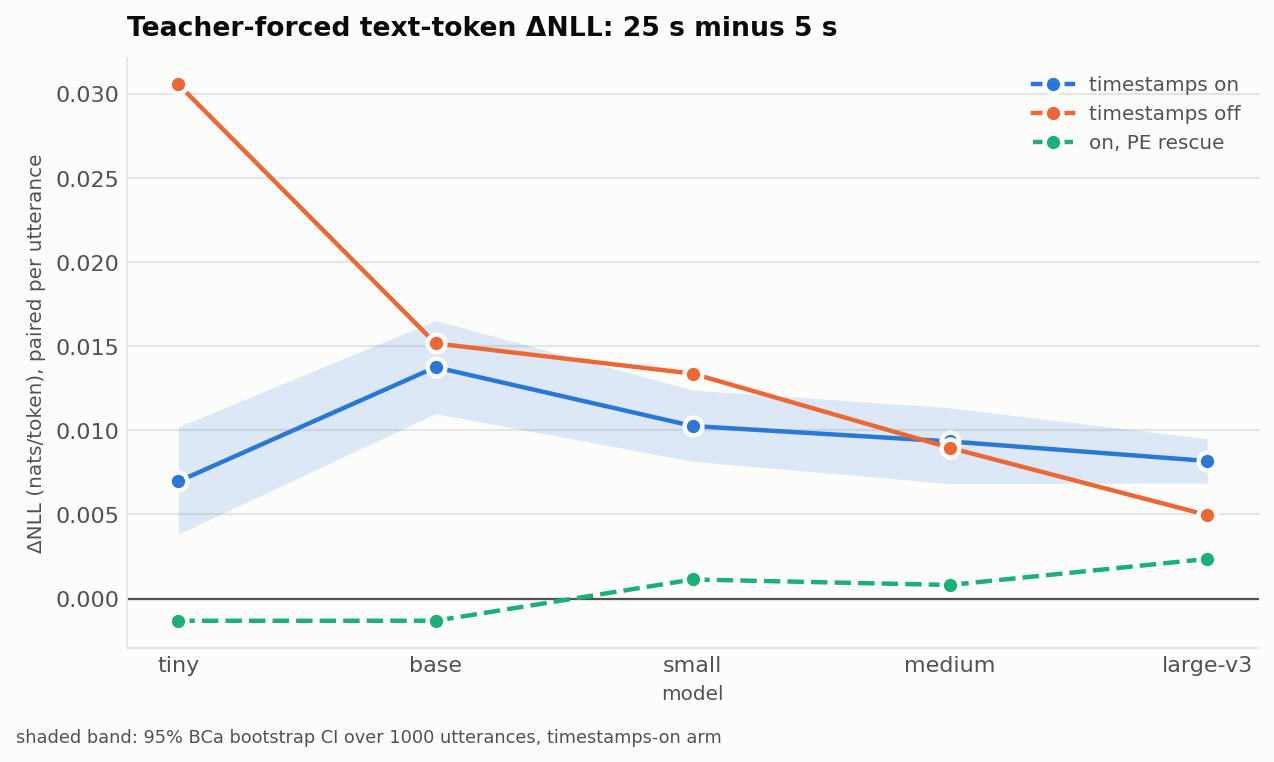

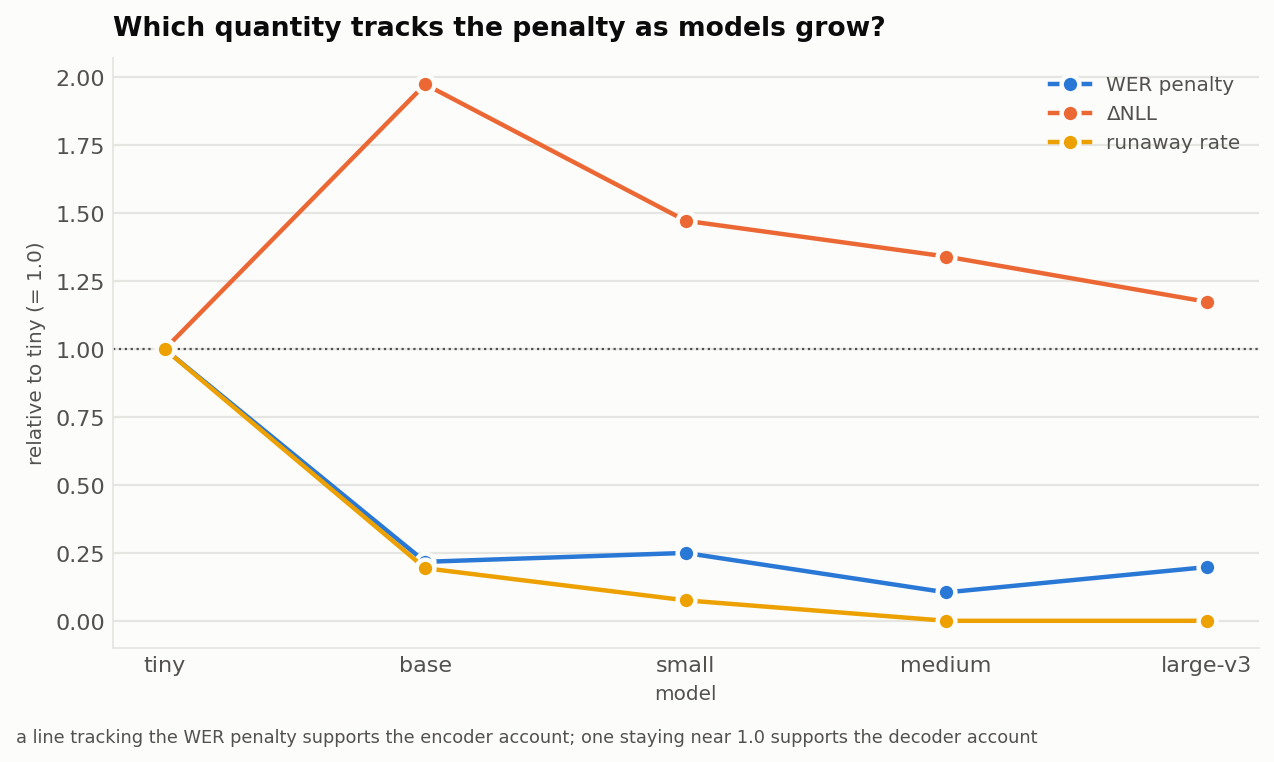

In [14]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e5e2"
BLUE, ORANGE, GREEN, AMBER = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
X = np.arange(len(MODELS_DONE))


def _frame(ax, title, ylab):
    ax.set_facecolor(SURFACE)
    ax.grid(True, axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.set_xticks(X); ax.set_xticklabels(MODELS_DONE, color=INK2)
    ax.tick_params(colors=INK2, length=0)
    ax.set_title(title, color=INK, fontsize=12, fontweight="bold", loc="left", pad=10)
    ax.set_ylabel(ylab, color=INK2, fontsize=9)


# --- figure 1: dNLL by scale -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.0, 4.6), dpi=160)
fig.patch.set_facecolor(SURFACE)
series = [("timestamps on",  [NLL[(m, "on")]["dnll"] for m in MODELS_DONE],  BLUE,   "-"),
          ("timestamps off", [NLL[(m, "off")]["dnll"] for m in MODELS_DONE], ORANGE, "-"),
          ("on, PE rescue",  [NLL[(m, "on")]["dnll_rescue"] for m in MODELS_DONE], GREEN, "--")]
for lab, y, c, ls in series:
    ax.plot(X, y, ls, color=c, linewidth=2, marker="o", markersize=8,
            markeredgecolor=SURFACE, markeredgewidth=2, label=lab, zorder=3)
lo = [NLL[(m, "on")]["dnll_lo"] for m in MODELS_DONE]
hi = [NLL[(m, "on")]["dnll_hi"] for m in MODELS_DONE]
ax.fill_between(X, lo, hi, color=BLUE, alpha=0.15, linewidth=0, zorder=2)
ax.axhline(0, color=INK2, linewidth=1, zorder=1)
_frame(ax, "Teacher-forced text-token ΔNLL: 25 s minus 5 s",
       "ΔNLL (nats/token), paired per utterance")
ax.set_xlabel("model", color=INK2, fontsize=9)
leg = ax.legend(frameon=False, fontsize=9, loc="best")
for t in leg.get_texts():
    t.set_color(INK2)
fig.text(0.01, -0.02, "shaded band: 95% BCa bootstrap CI over 1000 utterances, timestamps-on arm",
         color=INK2, fontsize=8)
fig.tight_layout()
fig.savefig("expc_nll_vs_scale.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

# --- figure 2: the discriminator ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.0, 4.6), dpi=160)
fig.patch.set_facecolor(SURFACE)
for lab, key, c, ls in [("WER penalty", "penalty_norm", BLUE, "-"),
                        ("ΔNLL", "dnll_norm", ORANGE, "-"),
                        ("runaway rate", "runaway_norm", AMBER, "-")]:
    ax.plot(X, [VERDICT[m][key] for m in MODELS_DONE], ls, color=c, linewidth=2, marker="o",
            markersize=8, markeredgecolor=SURFACE, markeredgewidth=2, label=lab, zorder=3)
ax.axhline(1.0, color=INK2, linewidth=1, linestyle=":", zorder=1)
_frame(ax, "Which quantity tracks the penalty as models grow?",
       f"relative to {MODELS_DONE[0]} (= 1.0)")
ax.set_xlabel("model", color=INK2, fontsize=9)
leg = ax.legend(frameon=False, fontsize=9, loc="best")
for t in leg.get_texts():
    t.set_color(INK2)
fig.text(0.01, -0.02, "a line tracking the WER penalty supports the encoder account; "
                      "one staying near 1.0 supports the decoder account",
         color=INK2, fontsize=8)
fig.tight_layout()
fig.savefig("expc_accounts.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

## 13. Write results and verify

Two files, split by what they carry:

- **`expc_results_full.csv`** (Drive only, gitignored) — every column including the hypothesis text.
- **`expc_per_utterance.csv`** (git-safe) — the same rows with `text` dropped. Every remaining
  value is asserted numeric apart from the structural identifiers `model`/`cond`/`timestamps` and
  `path`/`speaker`/`region`, which already appear in the committed `corpus_digests.json` and carry
  no transcript content.

The assertion is a guard, not a formality: saving a Colab notebook back to GitHub commits its
outputs, so a leaked column would be a licence violation in the repo history.

In [15]:
FORBIDDEN = {"text", "reference", "hypothesis", "ref", "hyp", "transcript"}
SAFE_FIELDS = [f for f in FIELDS if f != "text"]
IDENT = {"model", "cond", "timestamps", "path", "speaker", "region"}
assert not (set(SAFE_FIELDS) & FORBIDDEN), "a forbidden column survived into the git-safe file"

def _numericish(v):
    if v == "":
        return True
    try:
        float(v); return True
    except ValueError:
        return False

leaks = []
for r in rows:
    for k in SAFE_FIELDS:
        if k not in IDENT and not _numericish(r[k]):
            leaks.append((k, r[k]))
assert not leaks, f"non-numeric values in git-safe columns: {leaks[:5]}"

with open(SAFE_CSV, "w", newline="") as f:
    wr = csv.DictWriter(f, fieldnames=SAFE_FIELDS)
    wr.writeheader()
    for r in rows:
        wr.writerow({k: r[k] for k in SAFE_FIELDS})
print(f"wrote {len(rows)} rows x {len(SAFE_FIELDS)} columns -> {SAFE_CSV}")

def _jsonable(v):
    if isinstance(v, (np.floating, np.integer)):
        return v.item()
    if isinstance(v, dict):
        return {str(k): _jsonable(x) for k, x in v.items()}
    if isinstance(v, (list, tuple)):
        return [_jsonable(x) for x in v]
    return v

PROVENANCE["results"] = {
    "n_rows": len(rows), "models": MODELS_DONE,
    "full_csv": RESULTS_CSV, "safe_csv": SAFE_CSV,
    "safe_csv_sha256": sha256_file(SAFE_CSV),
    "nll": {f"{m}|{t}": _jsonable(v) for (m, t), v in NLL.items()},
    "pressure": {f"{m}|{t}|{c}": _jsonable(v) for (m, t, c), v in PRESSURE.items()},
    "behaviour": {f"{m}|{t}|{c}": _jsonable(v) for (m, t, c), v in BEHAV.items()},
    "verdict": _jsonable(VERDICT),
}
with open(PROV_JSON, "w") as f:
    json.dump(_jsonable(PROVENANCE), f, indent=1)
print(f"wrote provenance -> {PROV_JSON}")

# read the git-safe file back and confirm it round-trips, proving the write reached Drive
# rather than sitting in a FUSE buffer
back = list(csv.DictReader(open(SAFE_CSV, newline="")))
assert len(back) == len(rows)
assert all(b["path"] == r["path"] and b["nll_text"] == r["nll_text"]
           for b, r in zip(back, rows))
assert "text" not in back[0]
print(f"verified: {len(back)} rows read back from Drive, no text column")

wrote 30000 rows x 43 columns -> /content/drive/MyDrive/NAACL/expc_per_utterance.csv
wrote provenance -> /content/drive/MyDrive/NAACL/expc_provenance.json
verified: 30000 rows read back from Drive, no text column


## 14. Standalone reload

No GPU, no TIMIT, no earlier cells — run this alone to re-derive the headline numbers from the
git-safe file. Everything the verdict rests on is recoverable from paths and numbers, which is
exactly the point of keeping `n_ref_words` and the raw S/D/I counts per row.

In [16]:
import csv, numpy as np

SAFE = "/content/drive/MyDrive/NAACL/expc_per_utterance.csv"
rr = list(csv.DictReader(open(SAFE, newline="")))
G = {}
for r in rr:
    G.setdefault((r["model"], r["cond"], r["timestamps"]), []).append(r)
ms = sorted({r["model"] for r in rr},
            key=lambda m: ["tiny", "base", "small", "medium", "large-v3"].index(m))

def cw(m, c, t):
    v = G[(m, c, t)]
    return (sum(int(x["sub"]) + int(x["dele"]) + int(x["ins"]) for x in v) /
            sum(int(x["n_ref_words"]) for x in v))

def nl(m, c, t):
    return np.array([float(x["nll_text"]) for x in G[(m, c, t)]])

print(f"{len(rr)} rows | {len(ms)} models | {len(G[(ms[0],'C0','on')])} clips each\n")
print(f"{'model':>9s} | {'WER C0':>7s} {'WER C1':>7s} {'penalty':>8s} | "
      f"{'dNLL':>8s} {'dNLL rescue':>11s}")
for m in ms:
    w0, w1 = cw(m, "C0", "on"), cw(m, "C1", "on")
    d1 = float((nl(m, "C1", "on") - nl(m, "C0", "on")).mean())
    d2 = float((nl(m, "C2", "on") - nl(m, "C0", "on")).mean())
    print(f"{m:>9s} | {w0:7.4f} {w1:7.4f} {w1/w0:7.2f}x | {d1:+8.4f} {d2:+11.4f}")

30000 rows | 5 models | 1000 clips each

    model |  WER C0  WER C1  penalty |     dNLL dNLL rescue
     tiny |  0.1432  1.4612   10.21x |  +0.0070     -0.0013
     base |  0.0972  0.2915    3.00x |  +0.0137     -0.0013
    small |  0.0384  0.1267    3.30x |  +0.0103     +0.0011
   medium |  0.0263  0.0515    1.96x |  +0.0093     +0.0008
 large-v3 |  0.0151  0.0426    2.82x |  +0.0082     +0.0024
